# Experiment results

Reuses the exact same aggregation/plotting code from `experiments/results.py` (`build_summary_rows`,
`plot_efficiency_frontier`, `plot_latency_distribution`, `plot_per_field_accuracy`).

In [1]:
import sys
from pathlib import Path

# Jupyter's cwd is usually the notebook's own directory (experiments/), not the repo
# root, so `import experiments...` fails unless the repo root is on sys.path.
for _candidate in (Path.cwd(), Path.cwd().parent):
    if (_candidate / "experiments" / "results.py").exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

import pandas as pd
from IPython.display import Image, display

from experiments.config import DEFAULT_EXPERIMENT, GROUND_TRUTH_KEY, MODEL_REGISTRY
from experiments.results import (
    DEFAULT_EVALUATIONS_ROOT,
    DEFAULT_OUTPUT_DIR,
    DEFAULT_RUNS_ROOT,
    _discover_latest_runs,
    _model_color_map,
    _raw_wall_seconds,
    build_summary_rows,
    estimate_concurrent_runtime_sweep,
    plot_efficiency_frontier,
    plot_latency_distribution,
    plot_per_field_accuracy,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Select runs

Defaults to the most recent run per `model_key` under `experiments/runs`, matching
the CLI's default. To pin specific runs instead (mirrors `--run` on the CLI), set
`selected_runs` explicitly, e.g.:

```python
from experiments.results import _resolve_explicit_runs
selected_runs = _resolve_explicit_runs(["gpt-oss-120b__20260715T101500Z", ...], DEFAULT_RUNS_ROOT)
```

In [2]:
selected_runs = _discover_latest_runs(DEFAULT_RUNS_ROOT)
if not selected_runs:
    raise SystemExit(
        f"No runs found under {DEFAULT_RUNS_ROOT} -- run experiments/runner.py first."
    )

for model_key, run_dir in selected_runs.items():
    print(f"{model_key:>16}  ->  {run_dir}")

missing = set(DEFAULT_EXPERIMENT.model_keys) - set(selected_runs)
if missing:
    print(f"\nNo run found (yet) for: {sorted(missing)}")

   gpt-5.6-terra  ->  /projectnb/mcnet/kevin/infoextraction/govscape-extract/experiments/runs/baseline__gpt-5.6-terra__20260803T145714Z
   gemma4-12b-it  ->  /projectnb/mcnet/kevin/infoextraction/govscape-extract/experiments/runs/candidate__gemma4-12b-it__20260803T155852Z
    gpt-oss-120b  ->  /projectnb/mcnet/kevin/infoextraction/govscape-extract/experiments/runs/candidate__gpt-oss-120b__20260803T180031Z
olmo3-7b-instruct  ->  /projectnb/mcnet/kevin/infoextraction/govscape-extract/experiments/runs/candidate__olmo3-7b-instruct__20260803T155351Z
      qwen3-0.6b  ->  /projectnb/mcnet/kevin/infoextraction/govscape-extract/experiments/runs/candidate__qwen3-0.6b__20260803T145814Z
        qwen3-4b  ->  /projectnb/mcnet/kevin/infoextraction/govscape-extract/experiments/runs/candidate__qwen3-4b__20260803T151900Z

No run found (yet) for: ['gemma4-31b-it', 'gliner2-base']


## Summary table

In [3]:
rows = build_summary_rows(selected_runs, DEFAULT_EVALUATIONS_ROOT)
df = pd.DataFrame(rows)
display(df)

,model_key,role,n_documents,wall_seconds_total,wall_seconds_mean,wall_seconds_stdev,n_compared,coverage,overall_similarity_mean,overall_similarity_stdev,title_similarity,authors_similarity,publication_date_similarity,publication_date_raw_similarity,issuing_agency_similarity,performing_organization_similarity,document_type_similarity,report_number_similarity,series_similarity,jurisdiction_level_similarity,geographic_coverage_similarity
0,gpt-5.6-terra,ground_truth,1000,3067.615320,3.067615,1.853539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gemma4-12b-it,candidate,1000,5687.555532,5.687556,1.430417,1000.0,1.0,0.835163,0.121418,0.779905,0.874933,0.829000,0.827549,0.839828,0.945123,0.685000,0.805000,0.921299,0.845000,0.834154
2,gpt-oss-120b,candidate,1000,1887.469921,1.887470,0.526533,1000.0,1.0,0.842915,0.120140,0.774811,0.889709,0.881000,0.882930,0.832157,0.964724,0.573000,0.873000,0.943427,0.852000,0.805310
3,olmo3-7b-instruct,candidate,1000,2563.585231,2.566151,0.635982,999.0,1.0,0.684261,0.147437,0.681924,0.823312,0.609889,0.614077,0.697822,0.895792,0.389389,0.807808,0.925926,0.696697,0.384230
4,qwen3-0.6b,candidate,1000,318.820109,0.436740,0.113838,730.0,1.0,0.475288,0.180682,0.636021,0.744039,0.488717,0.498374,0.438004,0.514516,0.212329,0.367123,0.567197,0.380822,0.381028
5,qwen3-4b,candidate,1000,1680.028426,1.680028,0.421537,1000.0,1.0,0.724787,0.135274,0.710778,0.853901,0.723537,0.741168,0.646528,0.931072,0.473000,0.777000,0.909213,0.675000,0.531462


## Plots


In [4]:
plots_dir = DEFAULT_OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
model_color = _model_color_map(list(selected_runs))

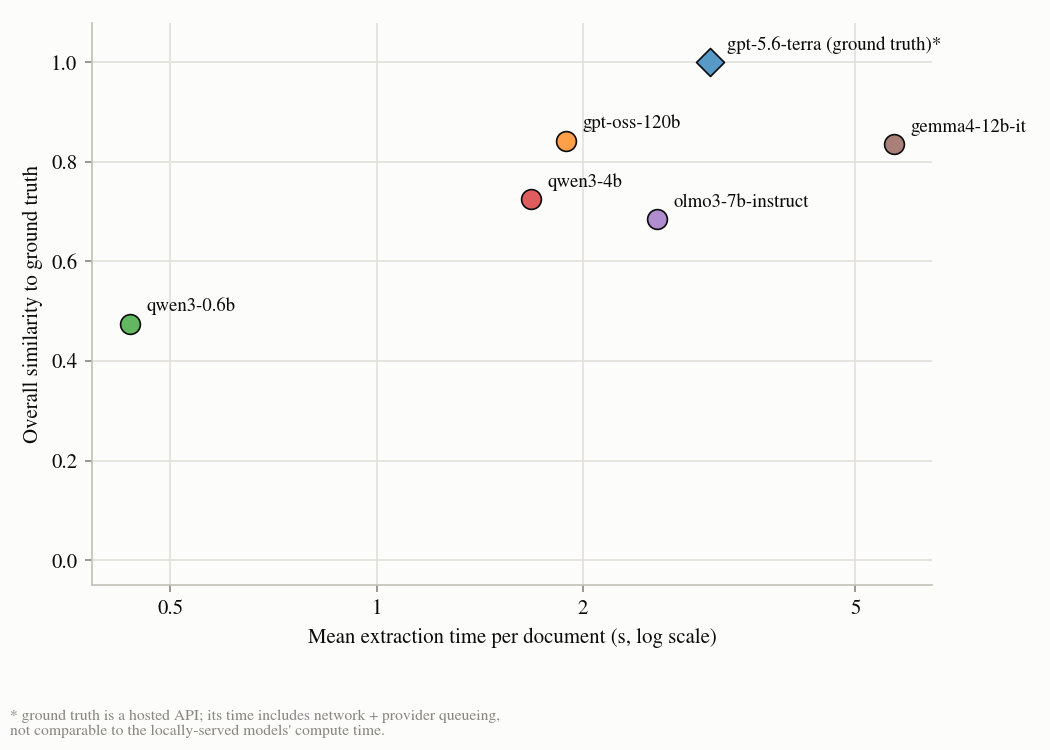

In [5]:
# Time vs. accuracy
path = plots_dir / "efficiency_frontier.png"
plot_efficiency_frontier(rows, path, model_color)
display(Image(filename=str(path)))

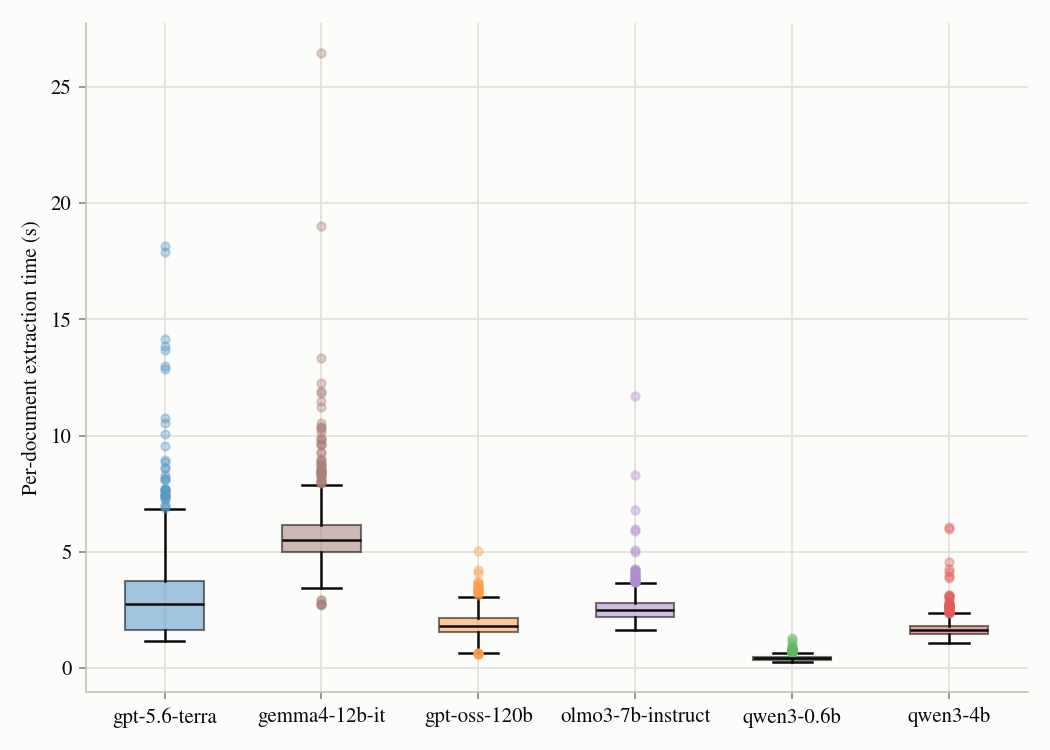

In [6]:
# Latency distribution
path = plots_dir / "latency_distribution.png"
plot_latency_distribution(selected_runs, path, model_color)
display(Image(filename=str(path)))

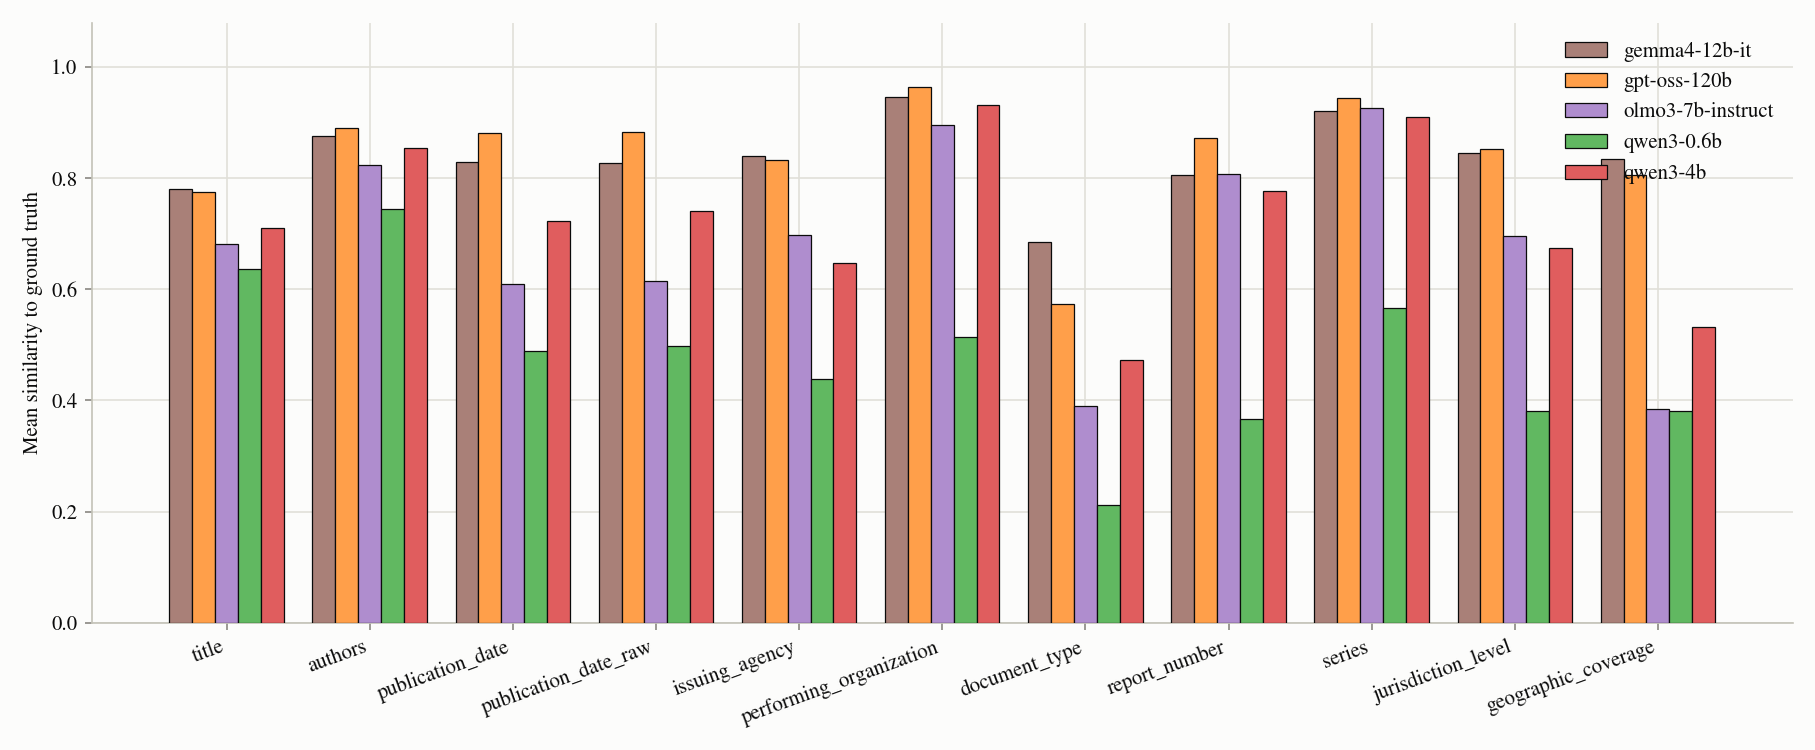

In [7]:
# Per-field accuracy
path = plots_dir / "per_field_accuracy.png"
plot_per_field_accuracy(rows, path, model_color)
display(Image(filename=str(path)))

## Runtime estimation


In [10]:
N_DOCUMENTS = 10_000_000
CONCURRENCIES = [4, 8, 16]
SCALING_EFFICIENCIES = [1.0, 0.5]  # 1.0 = optimistic upper bound; 0.5 = efficiency reduced to half

candidate_models = [row["model_key"] for row in rows if row["model_key"] != GROUND_TRUTH_KEY]

projection_rows = []
for model_key in candidate_models:
    projection_rows.extend(
        estimate_concurrent_runtime_sweep(model_key, N_DOCUMENTS, CONCURRENCIES, SCALING_EFFICIENCIES)
    )
projection_df = pd.DataFrame(projection_rows)

projected_hours = projection_df.pivot_table(
    index=["model_key", "scaling_efficiency"],
    columns="concurrency",
    values="projected_hours",
).round(1)
display(projected_hours)

concurrency                               4       8       16
model_key         scaling_efficiency                        
gemma4-12b-it     0.5                 7899.4  3949.7  1974.8
                  1.0                 3949.7  1974.8   987.4
gpt-oss-120b      0.5                 2621.5  1310.7   655.4
                  1.0                 1310.7   655.4   327.7
olmo3-7b-instruct 0.5                 3564.1  1782.0   891.0
                  1.0                 1782.0   891.0   445.5
qwen3-0.6b        0.5                  606.6   303.3   151.6
                  1.0                  303.3   151.6    75.8
qwen3-4b          0.5                 2333.4  1166.7   583.3
                  1.0                 1166.7   583.3   291.7